# Score Distribution: TNFA Binders vs ZINC Training Data

In [62]:
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, QED
import matplotlib.pyplot as plt
import gzip, sys, os, importlib

sys.path.insert(0, "/Users/kaitlynramesh/CBB_5801/0416_MolOpt/")

import tnfa_oracle; importlib.reload(tnfa_oracle)
from tnfa_oracle import batch_score_components, NOVELTY_THRESHOLD

In [63]:
SEED = 42
N_ZINC = 500
BASE = "/Users/kaitlynramesh/CBB_5801/0416_MolOpt/"

# --- JT-VAE predicted binders ---
cand_path = os.path.join(BASE, "results", "jtvae_tnfa", "candidates_20260418_160911.csv")
cand_df = pd.read_csv(cand_path)
cand_smiles = cand_df["smiles"].dropna().tolist()
print(f"JT-VAE candidates: {len(cand_smiles)}")

# --- Top-100 known binders (by affinity) ---
top100_path = os.path.join(BASE, "data", "tnfa_jtvae", "top100_binders.txt")
top100_smiles = pd.read_csv(top100_path, header=None)[0].dropna().tolist()
print(f"Top-100 known binders: {len(top100_smiles)}")

# --- ZINC baseline ---
zinc_path = os.path.join(BASE, "mol_opt", "data", "zinc.csv.gz")
with gzip.open(zinc_path, "rt") as f:
    zinc_smiles = [line.strip() for line in f if line.strip() and not line.startswith("SMILES")]
rng = np.random.default_rng(SEED)
zinc_sample = rng.choice(zinc_smiles, size=N_ZINC, replace=False).tolist()
print(f"ZINC sample: {len(zinc_sample)}")

JT-VAE candidates: 245
Top-100 known binders: 100
ZINC sample: 500


In [64]:
print("Scoring JT-VAE candidates...")
cand_scored = batch_score_components(cand_smiles)
cand_scored["dataset"] = "JT-VAE predictions"

print("Scoring top-100 known binders...")
top100_scored = batch_score_components(top100_smiles)
top100_scored["dataset"] = "Top-100 known"

print("Scoring ZINC baseline...")
zinc_scored = batch_score_components(zinc_sample)
zinc_scored["dataset"] = "ZINC"

combined = pd.concat([zinc_scored, top100_scored, cand_scored], ignore_index=True)
print(combined.groupby("dataset")[["weighted_sim", "max_sim", "novelty", "qed", "final"]].describe().round(3))

Scoring JT-VAE candidates...


[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerat

Scoring top-100 known binders...
Scoring ZINC baseline...
                   weighted_sim                                            \
                          count   mean    std    min    25%    50%    75%   
dataset                                                                     
JT-VAE predictions        245.0  0.335  0.253  0.157  0.197  0.213  0.247   
Top-100 known             100.0  0.819  0.053  0.705  0.784  0.812  0.847   
ZINC                      500.0  0.030  0.072  0.000  0.000  0.000  0.000   

                          max_sim         ...    qed         final         \
                      max   count   mean  ...    75%    max  count   mean   
dataset                                   ...                               
JT-VAE predictions  0.923   245.0  0.383  ...  0.545  0.907  245.0  0.366   
Top-100 known       0.931   100.0  1.000  ...  0.388  0.593  100.0  0.673   
ZINC                0.315   500.0  0.034  ...  0.000  0.940  500.0  0.055   

                

[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerator
[17:50:05] DEPRECATION WARNING: please use MorganGenerat

In [65]:
cand_scored['smiles'] = cand_smiles

In [66]:
cand_scored

,weighted_sim,max_sim,novelty,is_novel,qed,final,dataset,smiles
0,0.834017,1.000000,0.000000,0,0.592980,0.761706,JT-VAE predictions,COc1ccc2c(c1F)C(=O)N(C[C@@]1(C#Cc3cccnc3)NC(=O...
1,0.922940,1.000000,0.000000,0,0.356623,0.753045,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
2,0.910262,1.000000,0.000000,0,0.336971,0.738275,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
3,0.905684,1.000000,0.000000,0,0.339425,0.735806,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
4,0.923196,1.000000,0.000000,0,0.291421,0.733663,JT-VAE predictions,COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4C...
...,...,...,...,...,...,...,...,...
240,0.179421,0.204724,0.795276,1,0.247476,0.199837,JT-VAE predictions,CCOC(=O)C(OC(=O)C1CC2(Cc3ccccc3C)Cc3cc(F)ccc3N...
241,0.196281,0.216216,0.783784,1,0.194279,0.195680,JT-VAE predictions,CCCN(C(=O)c1coc2cc(OC)c(OC)cc2c1=O)C1=CN(CCC(N...
242,0.193393,0.203125,0.796875,1,0.200362,0.195483,JT-VAE predictions,COc1cc(NC(=O)c2cn(CCn3cccn3)nc2C)cc(-c2n[nH]c(...
243,0.156884,0.159292,0.840708,1,0.232189,0.179476,JT-VAE predictions,CC(C)(OCOc1cc2c(cc1C=O)OC(=O)C2CC[NH+]1CCOCC1)...


In [69]:
novel_candidates = cand_scored[cand_scored['is_novel'] == 1]
novel_smiles = cand_scored.loc[cand_scored['is_novel'] == 1, 'smiles']
top10 = (
    novel_candidates[["weighted_sim", "max_sim", "novelty", "qed", "final"]]
    .assign(smiles=novel_candidates['smiles'])
    .sort_values("final", ascending=False)
    .head(10)
    [["smiles", "final", "max_sim", "novelty", "qed"]]
    .rename(columns={"final": "oracle_score", "max_sim": "tanimoto_max", "novelty": "novelty (1-sim)"})
    .reset_index(drop=True)
)
top10.index += 1
top10.round(4)

,smiles,oracle_score,tanimoto_max,novelty (1-sim),qed
1,Cc1ccnn1C(=O)CC1CN(C(=O)c2ccccc2)CC(=O)N1,0.4304,0.2283,0.7717,0.9066
2,COc1cccc(C2CCN(C(=O)CCn3[nH]c4cc(C)ccc4c3=O)C2...,0.4109,0.3111,0.6889,0.6777
3,CCN(Cc1ccc2c(c1)CCN2C)C(=O)C1(OC)C=CNC1,0.4075,0.2222,0.7778,0.8949
4,COc1ccc(C)c(CC2CN3C(=O)C(C(=O)Nc4ccccc4C)CC3CO...,0.3946,0.2376,0.7624,0.7723
5,CCOc1cc(C2(O)CC(=O)N(Cc3cccc(OC)c3)C2=O)cc2c1OCO2,0.3895,0.2500,0.7500,0.7423
6,COc1cccc(N(CC(=O)N2CCCC2)C(=O)c2cccc(C=O)c2)c1,0.3826,0.2366,0.7634,0.7376
7,CNc1cccc(C2CC3C(C(=O)OC)C(c4ccc(F)cc4)CN3C2=O)c1,0.3783,0.2000,0.8000,0.8257
8,COC(CO)C1CCN(C(=O)Cn2c(C)cc(C(=O)Nc3ccc4c(c3)O...,0.3782,0.2523,0.7477,0.6782
9,COCC(=O)N1CCC(C2Nc3ccc(N4CCN(Cc5ccc(F)cc5)CC4)...,0.3782,0.2571,0.7429,0.7063
10,Cc1cc(C2=NN(C(=O)COc3ccc(NC(=O)O)cc3C(=O)[O-])...,0.3724,0.2247,0.7753,0.7447


In [79]:
top10.to_csv('top_10_novel_candidates.csv', index=False)

In [ ]:
# out_path = os.path.join(BASE, "results", "jtvae_tnfa", "candidates_scored.csv")
# (
#     cand_scored
#     .rename(columns={"final": "oracle_score", "max_sim": "tanimoto_max", "novelty": "novelty_score"})
#     [["smiles", "oracle_score", "tanimoto_max", "novelty_score", "qed", "weighted_sim"]]
#     .sort_values("oracle_score", ascending=False)
#     .reset_index(drop=True)
#     .to_csv(out_path, index=False)
# )
# print(f"Saved {len(cand_smiles)} candidates → {out_path}")

In [56]:
top10.loc[3]['smiles']

'COc1ccc2c(c1)C(=O)N(C[C@@]1(C#Cc3ccc(C(N=O)N4CCN(C)CC4)cc3)NC(=O)NC1=O)C2'

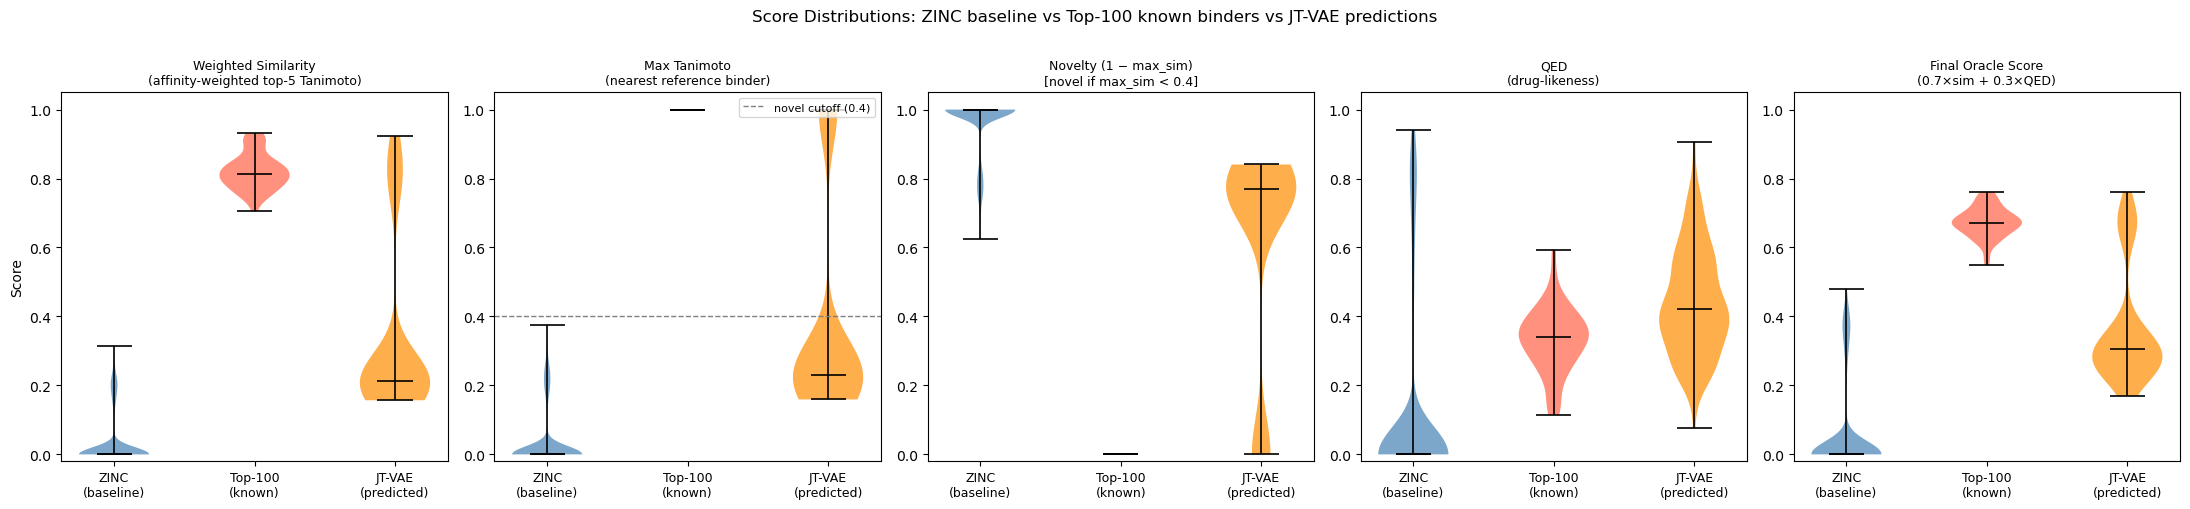

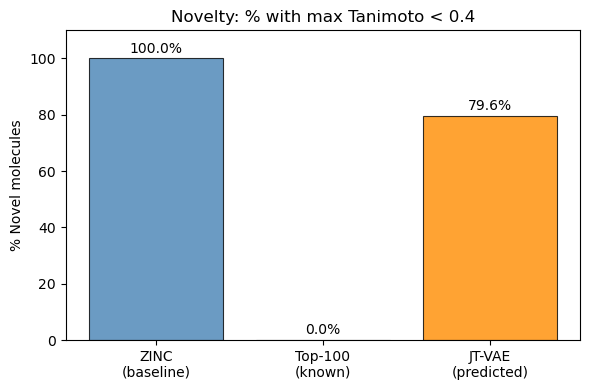

In [9]:
components = [
    ("weighted_sim", "Weighted Similarity\n(affinity-weighted top-5 Tanimoto)"),
    ("max_sim",      "Max Tanimoto\n(nearest reference binder)"),
    ("novelty",      f"Novelty (1 − max_sim)\n[novel if max_sim < {NOVELTY_THRESHOLD}]"),
    ("qed",          "QED\n(drug-likeness)"),
    ("final",        "Final Oracle Score\n(0.7×sim + 0.3×QED)"),
]

datasets  = ["ZINC",            "Top-100 known",   "JT-VAE predictions"]
labels    = ["ZINC\n(baseline)", "Top-100\n(known)", "JT-VAE\n(predicted)"]
colors    = ["steelblue",        "tomato",            "darkorange"]
positions = [1, 2, 3]

# --- Violin plots per score component ---
fig, axes = plt.subplots(1, len(components), figsize=(22, 5))

for ax, (col, title) in zip(axes, components):
    data = [combined.loc[combined["dataset"] == ds, col].values for ds in datasets]
    parts = ax.violinplot(data, positions=positions, showmedians=True, showextrema=True)
    for pc, color in zip(parts["bodies"], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    for key in ("cmedians", "cmins", "cmaxes", "cbars"):
        parts[key].set_color("black")
        parts[key].set_linewidth(1.2)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, fontsize=9)
    ax.set_ylim(-0.02, 1.05)
    ax.set_ylabel("Score" if ax == axes[0] else "")
    if col == "max_sim":
        ax.axhline(NOVELTY_THRESHOLD, color="gray", linestyle="--", linewidth=1,
                   label=f"novel cutoff ({NOVELTY_THRESHOLD})")
        ax.legend(fontsize=8)

fig.suptitle("Score Distributions: ZINC baseline vs Top-100 known binders vs JT-VAE predictions",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# --- % novel per dataset ---
fig, ax = plt.subplots(figsize=(6, 4))
pct_novel = [combined.loc[combined["dataset"] == ds, "is_novel"].mean() * 100 for ds in datasets]
bars = ax.bar(labels, pct_novel, color=colors, alpha=0.8, edgecolor="black", linewidth=0.8)
for bar, val in zip(bars, pct_novel):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1, f"{val:.1f}%",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("% Novel molecules")
ax.set_title(f"Novelty: % with max Tanimoto < {NOVELTY_THRESHOLD}")
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("novelty_pct.png", dpi=150, bbox_inches="tight")
plt.show()